In [6]:
import pandas as pd
import numpy as np
import os
import statsmodels.api as sm

# 1. Datei laden
file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)

# 2. Preis bereinigen
def clean_numeric(val):
    if pd.isna(val) or val == '': return np.nan
    # Entfernt Währungen, Tausenderpunkte und wandelt Komma in Punkt um
    s = str(val).replace('€', '').replace('EUR', '').replace('.', '').replace(',', '.').strip()
    try:
        return float(s)
    except:
        return np.nan

df['Preis'] = df['Preis'].apply(clean_numeric)

# 3. Kategorische Features encoden
# WICHTIG: Füge hier alle Text-Spalten hinzu, die du im Modell berücksichtigen willst
categorical_cols = ['Farbe']
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=float)

# 4. Zielvariable definieren
y = df_final['Preis']

# 5. X definieren: NUR numerische Spalten behalten und 'Preis' entfernen
# Das entfernt automatisch alle restlichen Text-Spalten (z.B. Namen oder IDs)
X = df_final.select_dtypes(include=[np.number]).drop(columns=['Preis'])

# 6. Fehlende Werte (NaNs) entfernen
# OLS kann nicht mit NaNs arbeiten
mask = y.notna() & X.notna().all(axis=1)
X = X[mask]
y = y[mask]

# Prüfen, ob noch Daten übrig sind
if len(X) == 0:
    print("Fehler: Keine Daten übrig nach der Bereinigung (alle Zeilen enthalten NaNs).")
else:
    # 7. Konstante hinzufügen und Modell rechnen
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Preis   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     4.003
Date:                Fri, 08 May 2026   Prob (F-statistic):           0.000368
Time:                        14:41:36   Log-Likelihood:                -317.16
No. Observations:                  60   AIC:                             658.3
Df Residuals:                      48   BIC:                             683.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Batteriezustand   

/Users/excalibrator/PycharmProjects/SMLab_iPhone17/.venv/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


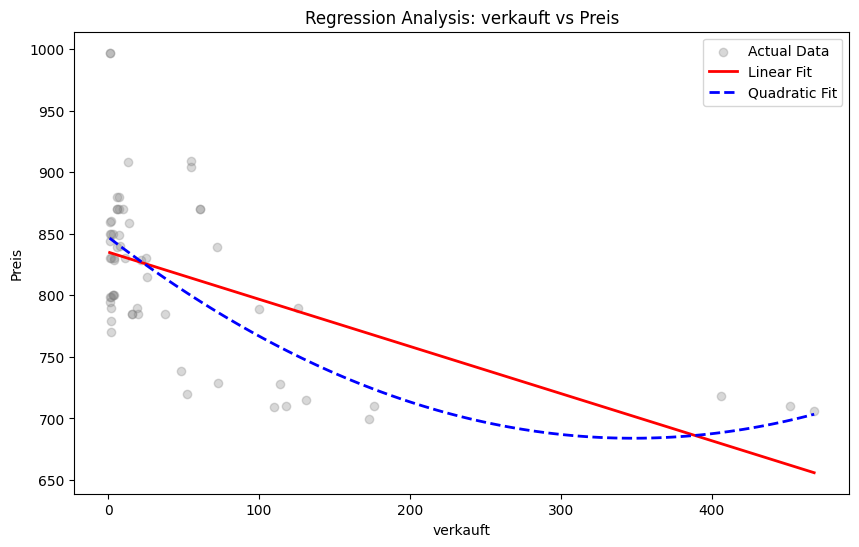

In [5]:
import matplotlib.pyplot as plt

# 1. CHOOSE YOUR X-AXIS VARIABLE
# Replace 'Year' with the actual column name from your Excel you want to plot
plot_var = X.columns[1] # This picks the first numeric column after the constant

# 2. CREATE PREDICTION DATA
# Generate 100 points for a smooth line
x_range = np.linspace(X[plot_var].min(), X[plot_var].max(), 100)

# Create a template where other variables are held at their mean
X_plot_lin = pd.DataFrame(index=range(100))
for col in X.columns:
    if col == "const": X_plot_lin[col] = 1.0
    elif col == plot_var: X_plot_lin[col] = x_range
    else: X_plot_lin[col] = X[col].mean()

# 3. SETUP QUADRATIC MODEL (For the Curve)
X_quad = X.copy()
quad_col_name = f"{plot_var}_squared"
X_quad[quad_col_name] = X_quad[plot_var] ** 2
model_quad = sm.OLS(y, X_quad).fit()

# Create prediction data for the curve
X_plot_quad = X_plot_lin.copy()
X_plot_quad[quad_col_name] = x_range ** 2
X_plot_quad = X_plot_quad[X_quad.columns.tolist()] # Ensure column order matches

# 4. PREDICT & PLOT
y_lin_pred = model.predict(X_plot_lin)
y_quad_pred = model_quad.predict(X_plot_quad)

plt.figure(figsize=(10, 6))
plt.scatter(X[plot_var], y, alpha=0.3, color='gray', label="Actual Data")
plt.plot(x_range, y_lin_pred, color='red', label="Linear Fit", linewidth=2)
plt.plot(x_range, y_quad_pred, color='blue', label="Quadratic Fit", linewidth=2, linestyle='--')

plt.xlabel(plot_var)
plt.ylabel("Preis")
plt.title(f"Regression Analysis: {plot_var} vs Preis")
plt.legend()
plt.show()
